<h1 style="text-align:center;">LAPTOP PRICE PREDICTION</h1>

In [92]:
#importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Data Exploration

In [93]:
df=pd.read_csv("laptop_data.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,2.0,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,3.0,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,4.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [94]:
df.columns


Index(['Unnamed: 0.1', 'Unnamed: 0', 'Company', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price'],
      dtype='object')

In [95]:
df.shape

(1303, 13)

<h1>Data Preprossing</h1>

## Data Cleaning

In [96]:
df.head(2)

,Unnamed: 0.1,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,0.0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,1.0,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


In [97]:
df.isnull().sum()

Unnamed: 0.1         0
Unnamed: 0          30
Company             30
TypeName            30
Inches              30
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              30
Price               30
dtype: int64

In [98]:
df.duplicated().sum()

np.int64(0)

In [99]:
df.drop(columns=['Unnamed: 0','Unnamed: 0.1'],inplace=True)

In [100]:
junk_values = ['?', float('NaN'), '']
junk_values_set = set(junk_values)
df= df[~df.apply(lambda row: any(val in junk_values_set for val in row), axis=1)]

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   object 
 3   ScreenResolution  1270 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   object 
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   object 
 10  Price             1270 non-null   float64
dtypes: float64(1), object(10)
memory usage: 121.9+ KB


In [102]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232


#### In above Data Cleaning 
##### null values, un necessary  coloumns 'Unnamed: 0','Unnamed: 0.1',duplicte values ,junk_values = ['?', float('NaN'), ''] are explored and droped/removed

## Exploratory Data Analysis and Feature Engineering 

In [103]:
# Modifying content in Ram and Weight
df["Ram"]=df["Ram"].str.replace("GB","")
df["Weight"]=df["Weight"].str.replace("kg","")
# Changing data type for  Ram and Weight
df["Ram"]=df["Ram"].astype("Int64")
df["Weight"]=df["Weight"].astype("float64")

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   object 
 3   ScreenResolution  1270 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   Int64  
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   float64
 10  Price             1270 non-null   float64
dtypes: Int64(1), float64(2), object(8)
memory usage: 123.1+ KB


In [105]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232


<Axes: xlabel='Price', ylabel='Density'>

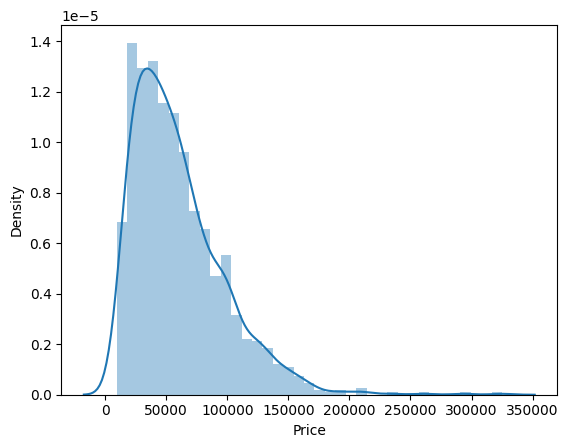

In [106]:
sns.distplot(df["Price"])

#### The Laptops whose price upto Rs:50,000 are more

<Axes: xlabel='Company'>

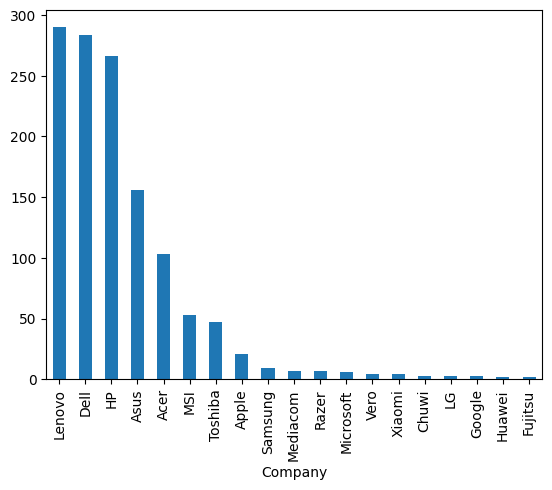

In [107]:
df["Company"].value_counts().plot(kind="bar")

#### Count of Lenovo Laptops are more

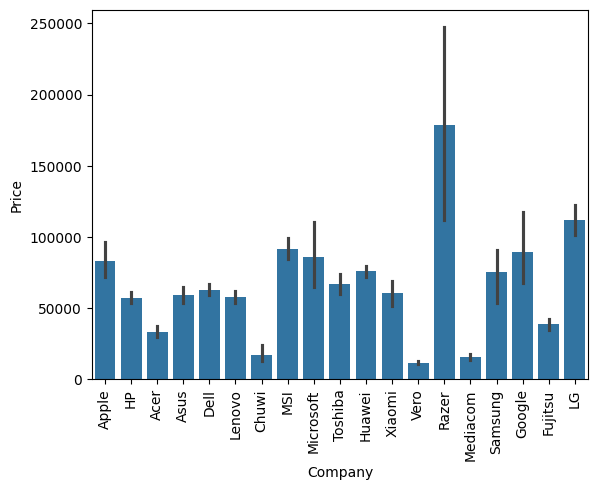

In [108]:
sns.barplot(x=df["Company"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

#### Razer laptops Are high in price upto Rs 250000

<Axes: xlabel='TypeName'>

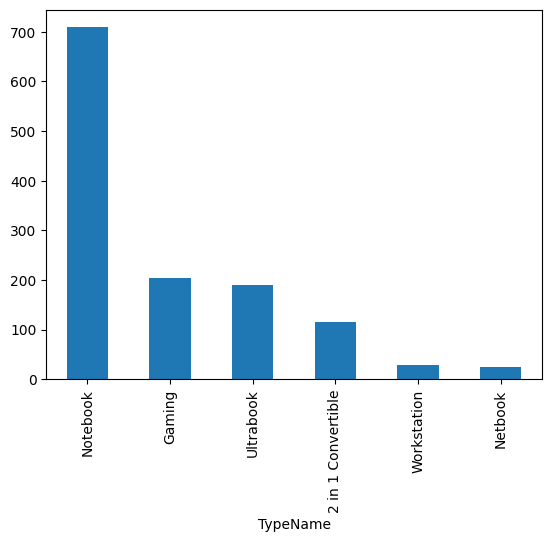

In [109]:
df["TypeName"].value_counts().plot(kind="bar")

#### Notebooks are high in count

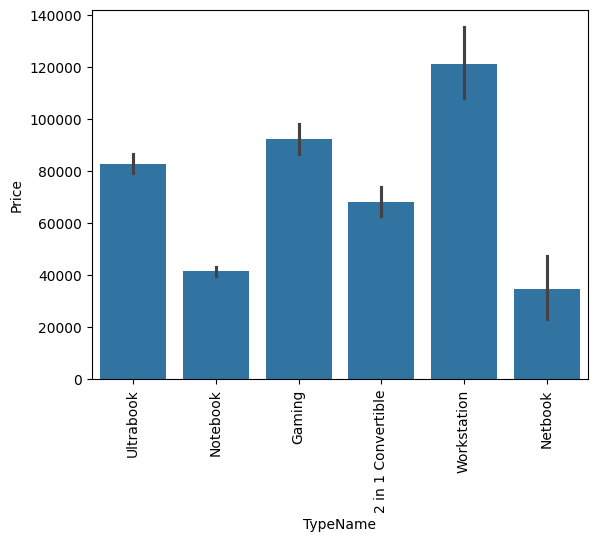

In [110]:
sns.barplot(x=df["TypeName"],y=df["Price"])
plt.xticks(rotation="vertical")
plt.show()

#### Workstation types are higher in price

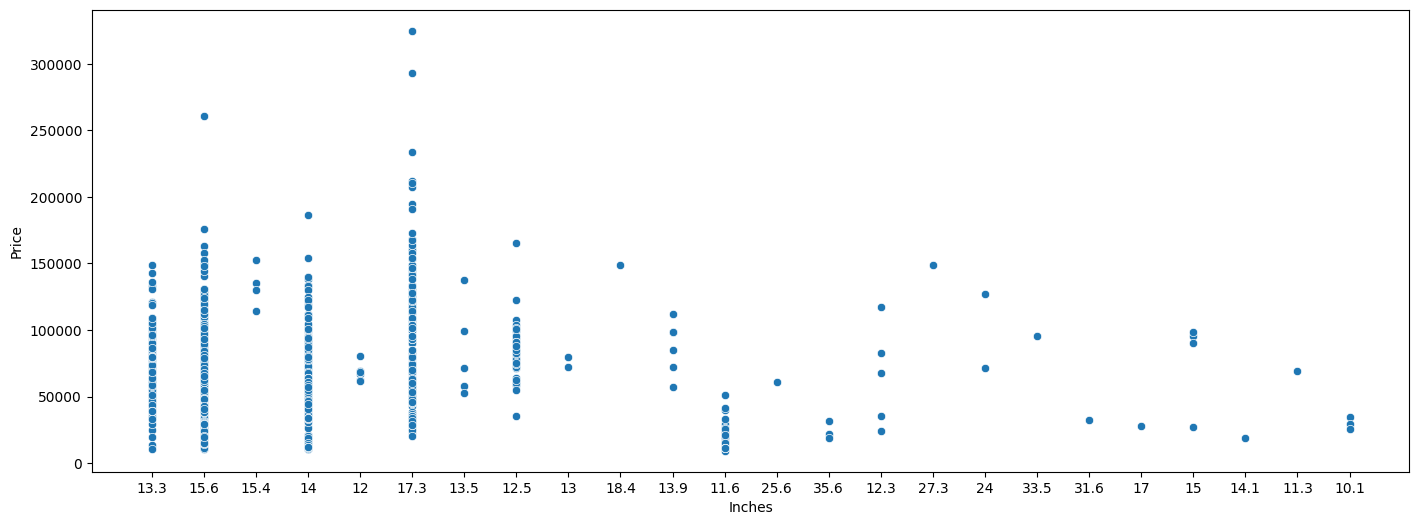

In [111]:
plt.figure(figsize=(17,6))  # Adjust the figure size as needed
sns.scatterplot(x="Inches", y="Price", data=df)  # Adjust the size of the points as needed
plt.show()

#### The above scatterplot define that 17.3 inches screen is high price

In [112]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                492
1366x768                                         274
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         52
Full HD / Touchscreen 1920x1080                   45
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  14
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160                9
IPS Panel 1366x768                                 7
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              6
IPS Panel Retina Display 2304x1440                 6
IPS Panel Retina Display 2560x1600                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [113]:
df["ScreenResolution"] = df["ScreenResolution"].astype(str)  # Convert the column to string type
df["Touchscreen"] = df["ScreenResolution"].apply(lambda x: 1 if "Touchscreen" in x else 0)

In [114]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

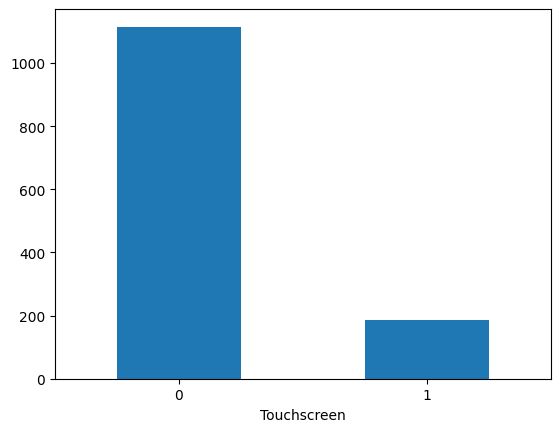

In [115]:
df["Touchscreen"].value_counts().plot(kind="bar")
plt.xticks(rotation="horizontal")

#### Non-Touch Screen(0) are more

<Axes: xlabel='Touchscreen', ylabel='Price'>

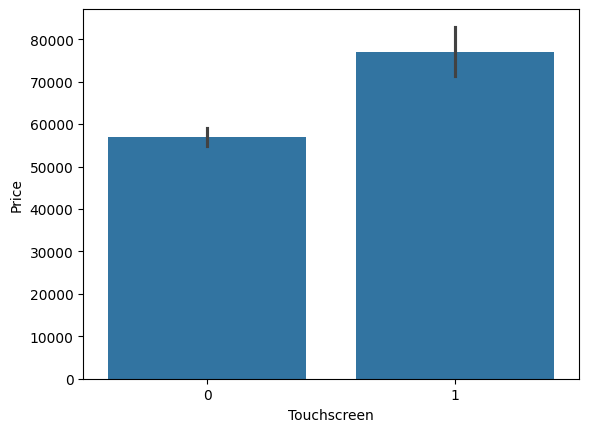

In [116]:
sns.barplot(x=df["Touchscreen"],y=df["Price"])

#### The above barplots define that Touch Screen Laptops are high in price above Rs:60,000 non Touch Screen are below

In [117]:
# Convert float values to empty string ''
df['ScreenResolution'] = df['ScreenResolution'].astype(str)
# Create a new column 'Ips' based on the presence of 'IPS' in 'ScreenResolution'
df["Ips"]=df["ScreenResolution"].apply(lambda x:1 if "IPS" in x else 0)

In [118]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0


<Axes: xlabel='Ips', ylabel='Price'>

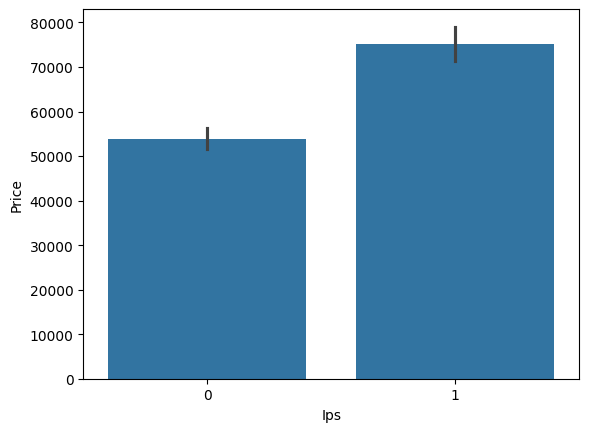

In [119]:
sns.barplot(x=df["Ips"],y=df["Price"])

#### IPS types of moniter have high price

In [120]:
df["ScreenResolution"].str.split("x")

0               [IPS Panel Retina Display 2560, 1600]
1                                         [1440, 900]
2                                [Full HD 1920, 1080]
3               [IPS Panel Retina Display 2880, 1800]
4               [IPS Panel Retina Display 2560, 1600]
                            ...                      
1298     [IPS Panel Full HD / Touchscreen 1920, 1080]
1299    [IPS Panel Quad HD+ / Touchscreen 3200, 1800]
1300                                      [1366, 768]
1301                                      [1366, 768]
1302                                      [1366, 768]
Name: ScreenResolution, Length: 1300, dtype: object

In [121]:
temp= df["ScreenResolution"].str.split("x",n=1,expand=True)

In [122]:
df["X_res"]=temp[0]
df["Y_res"]=temp[1]

In [123]:
df.head(3)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080


In [124]:
df['X_res'] = df['X_res'].str.replace(',', '').str.findall(r'(\d+\.?\d+)')
df['X_res'] = df['X_res'].apply(lambda x: x[0] if len(x) > 0 else None)

In [125]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900


In [126]:
df['X_res'] = df['X_res'].fillna(0).astype(int)
df['Y_res'] = df['Y_res'].fillna(0).astype(int)

In [127]:
df.head(2)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900


In [128]:
df["Inches"]=df["Inches"].astype("float64")

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1270 non-null   object 
 1   TypeName          1270 non-null   object 
 2   Inches            1270 non-null   float64
 3   ScreenResolution  1300 non-null   object 
 4   Cpu               1270 non-null   object 
 5   Ram               1270 non-null   Int64  
 6   Memory            1270 non-null   object 
 7   Gpu               1270 non-null   object 
 8   OpSys             1270 non-null   object 
 9   Weight            1270 non-null   float64
 10  Price             1270 non-null   float64
 11  Touchscreen       1300 non-null   int64  
 12  Ips               1300 non-null   int64  
 13  X_res             1300 non-null   int64  
 14  Y_res             1300 non-null   int64  
dtypes: Int64(1), float64(3), int64(4), object(7)
memory usage: 163.8+ KB


In [130]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
numeric_df.corr()['Price']

Inches         0.045028
Ram            0.687176
Weight         0.176689
Price          1.000000
Touchscreen    0.190070
Ips            0.256502
X_res          0.558245
Y_res          0.554788
Name: Price, dtype: float64

In [131]:
df['ppi'] = (((df['X_res']**2) + (df['Y_res']**2))**0.5/df['Inches']).astype('float')

In [132]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
numeric_df.corr()['Price']

Inches         0.045028
Ram            0.687176
Weight         0.176689
Price          1.000000
Touchscreen    0.190070
Ips            0.256502
X_res          0.558245
Y_res          0.554788
ppi            0.469340
Name: Price, dtype: float64

In [133]:
df.drop(columns=["ScreenResolution","X_res","Y_res","Inches"],inplace=True)

In [134]:
df.head(2)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940


In [135]:
df["Cpu"].value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       183
Intel Core i7 7700HQ 2.8GHz      141
Intel Core i7 7500U 2.7GHz       127
Intel Core i7 8550U 1.8GHz        71
Intel Core i5 8250U 1.6GHz        68
                                ... 
Intel Core i5 7200U 2.70GHz        1
Intel Core M M7-6Y75 1.2GHz        1
Intel Core M 6Y54 1.1GHz           1
AMD E-Series 9000 2.2GHz           1
Samsung Cortex A72&A53 2.0GHz      1
Name: count, Length: 118, dtype: int64

In [136]:
# Convert the "Cpu" column to string type
df['Cpu'] = df['Cpu'].astype(str)

# Apply the lambda function to create the "Cpu Name" column
df['Cpu_Name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[0:3]) if isinstance(x, str) else None)

In [137]:
df.head(2)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5


In [138]:
def fetch_processor(text):
    if text == 'Intel Core i7' or text == 'Intel Core i5' or text == 'Intel Core i3':
        return text
    else:
        if text.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

In [139]:
df['Cpu_brand'] = df['Cpu_Name'].apply(fetch_processor)

In [140]:
df.iloc[83:87]

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_Name,Cpu_brand
83,Lenovo,Notebook,AMD A6-Series 9220 2.5GHz,4,128GB SSD,AMD R4 Graphics,Windows 10,2.20,21258.72,0,0,141.211998,AMD A6-Series 9220,AMD Processor
84,Acer,Notebook,AMD A9-Series 9420 3GHz,4,1TB HDD,AMD Radeon R5,Windows 10,2.10,21045.60,0,0,100.454670,AMD A9-Series 9420,AMD Processor
85,Dell,Gaming,Intel Core i7 7700HQ 2.8GHz,16,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050 Ti,Windows 10,2.65,71874.72,0,1,141.211998,Intel Core i7,Intel Core i7
86,HP,Ultrabook,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Nvidia GeForce GTX 940MX,Windows 10,1.83,37242.72,0,1,141.211998,Intel Core i7,Intel Core i7


In [141]:
df.drop(columns=['Cpu','Cpu_Name'],inplace=True)

In [142]:
df.head(2)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5


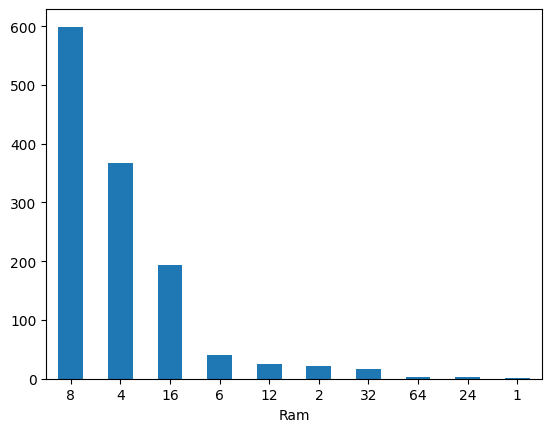

In [143]:
df['Ram'].value_counts().plot(kind='bar')
plt.xticks(rotation='horizontal')
plt.show()

#### 8GB RAM count is more

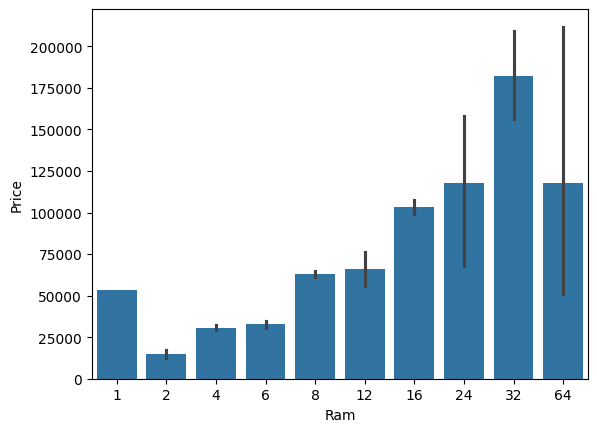

In [144]:
sns.barplot(x=df['Ram'],y=df['Price'])
plt.xticks(rotation='horizontal')
plt.show()

### 64GB RAM price is high

In [145]:
df['Memory'].value_counts()

Memory
256GB SSD                        399
1TB HDD                          217
500GB HDD                        130
512GB SSD                        116
128GB SSD +  1TB HDD              92
128GB SSD                         74
256GB SSD +  1TB HDD              71
32GB Flash Storage                37
2TB HDD                           16
64GB Flash Storage                14
512GB SSD +  1TB HDD              14
1TB SSD                           13
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
128GB Flash Storage                4
180GB SSD                          4
16GB SSD                           3
512GB SSD +  2TB HDD               3
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
64GB SSD                       

In [146]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in x else 0)

df['first'] = df['first'].str.replace(r'\D', '')

df["second"].fillna("0", inplace = True)

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in x else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in x else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in x else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in x else 0)

# Remove non-numeric characters from 'first' column
df['first'] = df['first'].str.extract('(\d+)')
df['second'] = df['second'].str.extract('(\d+)')
# df['second'] = df['second'].str.replace(r'\D', '')

df['first'].fillna(0, inplace=True)
df["second"].fillna(0, inplace=True)

df["first"] = df["first"].astype(int)
df["second"] = df["second"].astype(int)


df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)

In [147]:
df.head(2)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128


In [148]:
df.drop(columns=['Memory'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        1270 non-null   object 
 1   TypeName       1270 non-null   object 
 2   Ram            1270 non-null   Int64  
 3   Gpu            1270 non-null   object 
 4   OpSys          1270 non-null   object 
 5   Weight         1270 non-null   float64
 6   Price          1270 non-null   float64
 7   Touchscreen    1300 non-null   int64  
 8   Ips            1300 non-null   int64  
 9   ppi            1270 non-null   float64
 10  Cpu_brand      1300 non-null   object 
 11  HDD            1300 non-null   int64  
 12  SSD            1300 non-null   int64  
 13  Hybrid         1300 non-null   int64  
 14  Flash_Storage  1300 non-null   int64  
dtypes: Int64(1), float64(3), int64(6), object(5)
memory usage: 163.8+ KB


In [149]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
numeric_df.corr()['Price']

Ram              0.687176
Weight           0.176689
Price            1.000000
Touchscreen      0.190070
Ips              0.256502
ppi              0.469340
HDD             -0.094097
SSD              0.669050
Hybrid           0.008035
Flash_Storage   -0.038106
Name: Price, dtype: float64

In [150]:
df.drop(columns=['Hybrid','Flash_Storage'],inplace=True)
df.head(2)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0


In [151]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      271
Intel HD Graphics 520      181
Intel UHD Graphics 620      65
Nvidia GeForce GTX 1050     64
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [152]:
# Convert the "gpu" column to string type
df['Gpu'] = df['Gpu'].astype(str)
# Apply the lambda function to create the "Cpu Name" column
df['Gpu_brand'] = df['Gpu'].apply(lambda x: " ".join(x.split()[0:3]) if isinstance(x, str) else None)

In [153]:
df.head(2)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics


In [154]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel HD Graphics         622
Nvidia GeForce GTX        231
Intel UHD Graphics         65
AMD Radeon R5              53
Nvidia GeForce 940MX       42
AMD Radeon 530             39
nan                        30
Nvidia GeForce 930MX       25
AMD Radeon R7              25
Nvidia GeForce 920MX       17
AMD Radeon 520             16
Nvidia GeForce MX150       15
AMD Radeon RX              12
Intel Iris Plus            10
AMD Radeon R2               9
AMD Radeon R4               8
Nvidia Quadro M1200         8
Nvidia GeForce 920M         6
Nvidia GeForce MX130        6
Nvidia GeForce 930M         5
Nvidia Quadro M620          5
Nvidia GeForce GT           5
Nvidia Quadro M1000M        4
AMD Radeon Pro              3
Nvidia Quadro M2200M        3
Nvidia GeForce 150MX        3
Intel Iris Graphics         3
AMD FirePro W4190M          3
Nvidia Quadro M520M         2
Nvidia Quadro M2000M        2
Nvidia Quadro M2200         2
Intel Iris Pro              1
AMD R17M-M1-70              1


In [155]:
df = df[df['Gpu_brand'] != 'ARM']

In [156]:
df['Gpu_brand'].value_counts()

Gpu_brand
Intel HD Graphics         622
Nvidia GeForce GTX        231
Intel UHD Graphics         65
AMD Radeon R5              53
Nvidia GeForce 940MX       42
AMD Radeon 530             39
nan                        30
Nvidia GeForce 930MX       25
AMD Radeon R7              25
Nvidia GeForce 920MX       17
AMD Radeon 520             16
Nvidia GeForce MX150       15
AMD Radeon RX              12
Intel Iris Plus            10
AMD Radeon R2               9
AMD Radeon R4               8
Nvidia Quadro M1200         8
Nvidia GeForce 920M         6
Nvidia GeForce MX130        6
Nvidia GeForce 930M         5
Nvidia Quadro M620          5
Nvidia GeForce GT           5
Nvidia Quadro M1000M        4
AMD Radeon Pro              3
Nvidia Quadro M2200M        3
Nvidia GeForce 150MX        3
Intel Iris Graphics         3
AMD FirePro W4190M          3
Nvidia Quadro M520M         2
Nvidia Quadro M2000M        2
Nvidia Quadro M2200         2
Intel Iris Pro              1
AMD R17M-M1-70              1


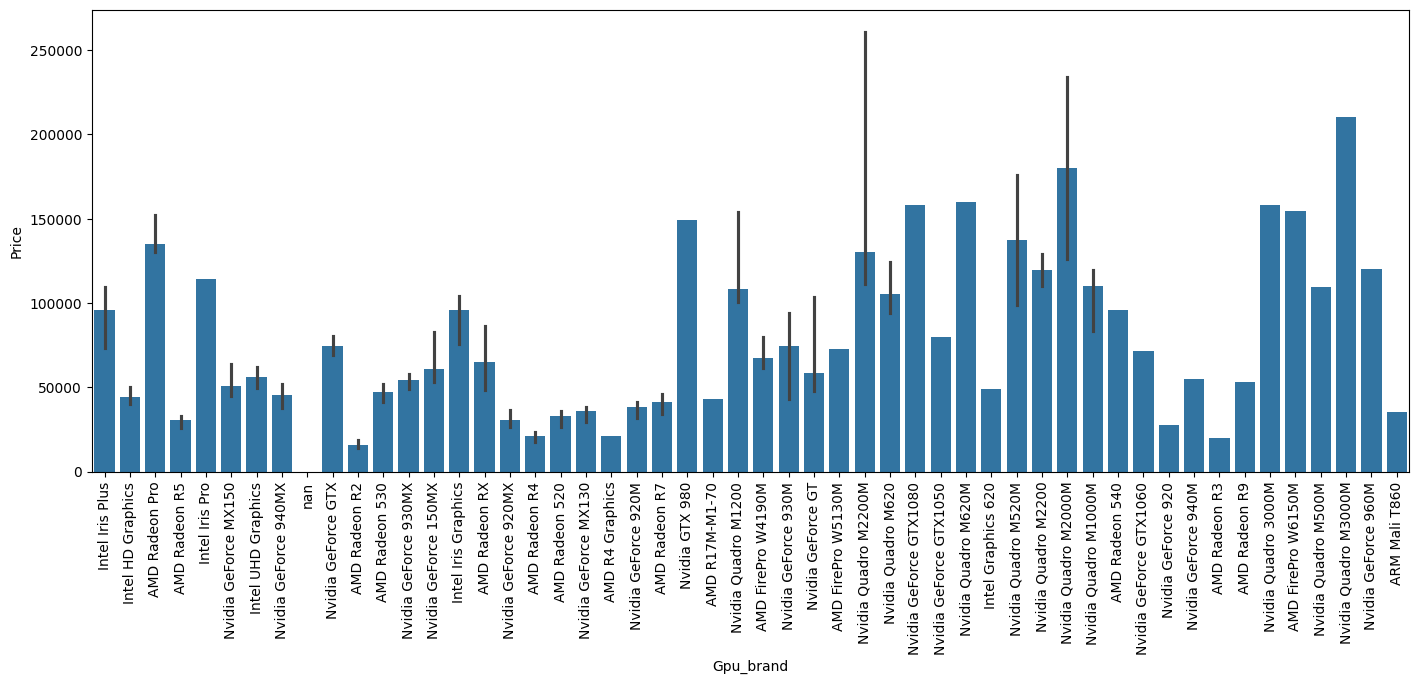

In [157]:
plt.figure(figsize=(17,6))
sns.barplot(x=df['Gpu_brand'],y=df['Price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

#### NIVIDIA Quadro M3000M has higher price

In [158]:
df.drop(columns=['Gpu'],inplace=True)
df.head(2)

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics


In [159]:
df['OpSys'].value_counts()

OpSys
Windows 10      1044
No OS             63
Linux             61
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            1
Name: count, dtype: int64

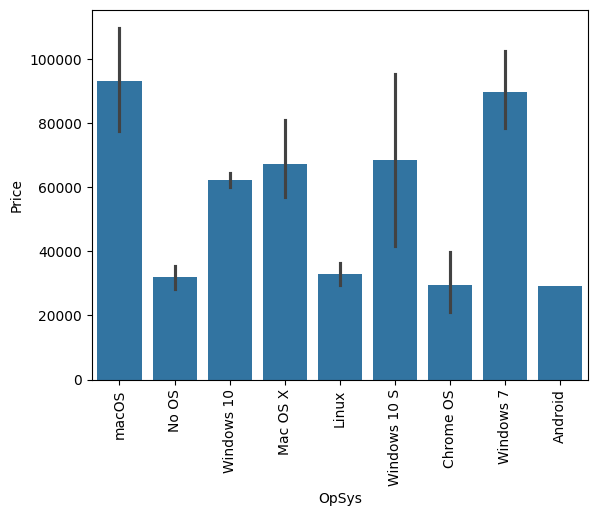

In [160]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

#### Mac OS is high price

In [161]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'
    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

In [162]:
df['os'] = df['OpSys'].apply(cat_os)

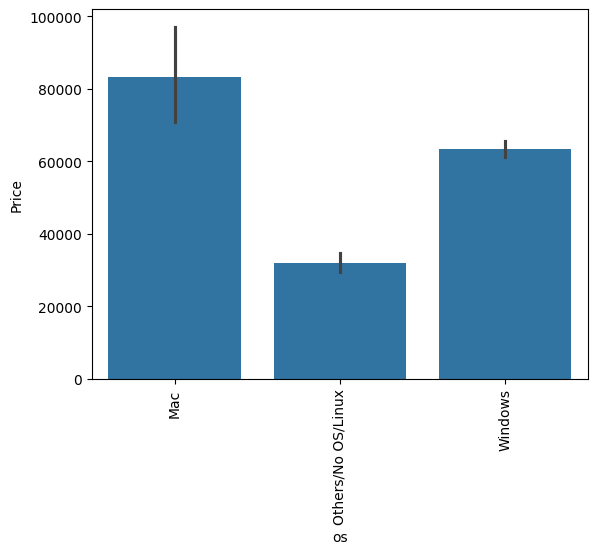

In [163]:
sns.barplot(x=df['os'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.show()

#### After excluding MAC and WINDOWS and compressing other type of OS as Other/No OS/Windows clearly shows MAC OS prise is high

In [164]:
df.drop(columns=['OpSys'],inplace=True)
df.head(2)

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics,Mac


<Axes: xlabel='Weight', ylabel='Density'>

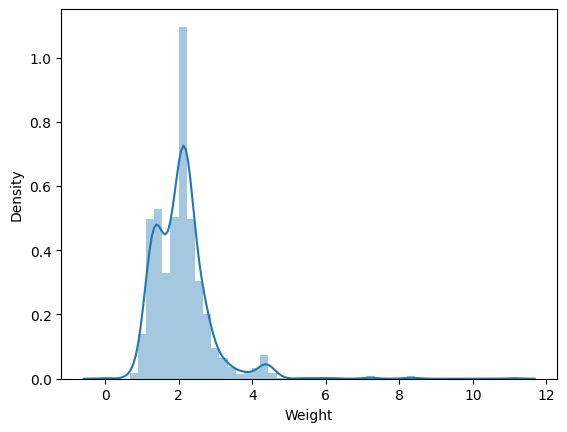

In [165]:
sns.distplot(df['Weight'])

#### Most of the laptop weights resides between 0 to 4KGs

<Axes: xlabel='Weight', ylabel='Price'>

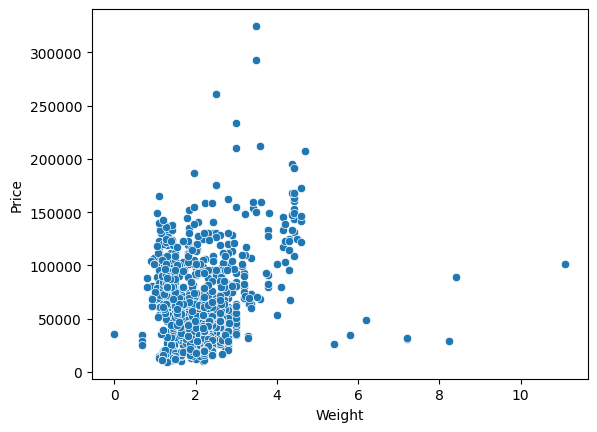

In [166]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

#### Highest price laptops betwee 2 to 4KGs is more than Rs300000 Least Price is less than Rs 50000

In [167]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
numeric_df.corr()['Price']

Ram            0.687176
Weight         0.176689
Price          1.000000
Touchscreen    0.190070
Ips            0.256502
ppi            0.469340
HDD           -0.094097
SSD            0.669050
Name: Price, dtype: float64

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1300 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1270 non-null   object 
 1   TypeName     1270 non-null   object 
 2   Ram          1270 non-null   Int64  
 3   Weight       1270 non-null   float64
 4   Price        1270 non-null   float64
 5   Touchscreen  1300 non-null   int64  
 6   Ips          1300 non-null   int64  
 7   ppi          1270 non-null   float64
 8   Cpu_brand    1300 non-null   object 
 9   HDD          1300 non-null   int64  
 10  SSD          1300 non-null   int64  
 11  Gpu_brand    1300 non-null   object 
 12  os           1300 non-null   object 
dtypes: Int64(1), float64(3), int64(4), object(5)
memory usage: 143.5+ KB


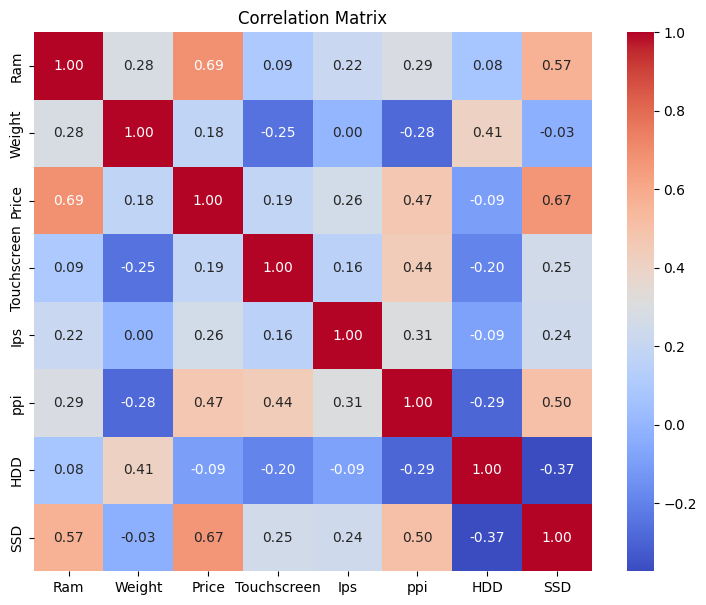

In [169]:
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
numeric_df = numeric_df.astype(float)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(9,7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [170]:
df.head()

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics,Mac
2,HP,Notebook,8,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel HD Graphics,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD Radeon Pro,Mac
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel Iris Plus,Mac


#### In above Feature Engineering 
##### Screen-Resolution(Pixel Resolution) is smplified to PPI(Pixel Per Inch)
##### Screen-Resolution is splited as IPS panel and Touch Screen and Categorized as 0(if no) and 1(if yes)
##### Memory is Splitted and Categorized to HDD and SSD and Categorized as 0(if no) and 1(if yes)
##### Operating System is Categorized to Mac OS , Others/No OS/Linux, Windows
##### Data in CPU,Weight,GPU,Ram is modified and also there data types also changed

### Splitting the data in X(Features) and Y(Target)

In [171]:
df.dropna(inplace=True)
X = df.drop(columns=['Price'])
Y = df['Price']

In [172]:
X

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac
1,Apple,Ultrabook,8,1.34,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics,Mac
2,HP,Notebook,8,1.86,0,0,141.211998,Intel Core i5,0,256,Intel HD Graphics,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,0,1,220.534624,Intel Core i7,0,512,AMD Radeon Pro,Mac
4,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,256,Intel Iris Plus,Mac
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,4,1.80,1,1,157.350512,Intel Core i7,0,128,Intel HD Graphics,Windows
1299,Lenovo,2 in 1 Convertible,16,1.30,1,1,276.053530,Intel Core i7,0,512,Intel HD Graphics,Windows
1300,Lenovo,Notebook,2,1.50,0,0,111.935204,Other Intel Processor,0,0,Intel HD Graphics,Windows
1301,HP,Notebook,6,2.19,0,0,100.454670,Intel Core i7,1000,0,AMD Radeon R5,Windows


In [173]:
Y

0        71378.6832
1        47895.5232
2        30636.0000
3       135195.3360
4        96095.8080
           ...     
1298     33992.6400
1299     79866.7200
1300     12201.1200
1301     40705.9200
1302     19660.3200
Name: Price, Length: 1270, dtype: float64

In [174]:
df.head(2)

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel HD Graphics,Mac


### Model Selection and Evaluation

In [175]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor ,GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_log_error,mean_squared_error
import re

#### Training and Testing the X,Y

In [176]:
# Splitting the dataset into the training set and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [177]:
# Define preprocessing steps for numeric and categorical features
numeric_features = ['Ram', 'Weight', 'ppi', 'HDD', 'SSD']
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_brand', 'os']
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

#### LINEAR REGRESSION

In [178]:
# Define Linear Regression
lr_models = LinearRegression()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', lr_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))

print("Linear Regressor:")
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

Linear Regressor:
  MSE: 279492847.2771445
  RMSE: 16718.03957637212
  R2 Score: 0.7486365884962196
  RMSLE: 0.3410133418887207


#### RANDOM FOREST REGRESSION

In [179]:
# Define the Random Forest Regressor
rf_model = RandomForestRegressor()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', rf_model)])

# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))

print("Random Forest Regressor:")
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

Random Forest Regressor:
  MSE: 197615708.6048971
  RMSE: 14057.58544718463
  R2 Score: 0.8222732382399471
  RMSLE: 0.2137650251222956


#### GRADIENT BOOSTING REGRESSION

In [180]:
# Define Gradient Boosting Regressor
gb_models = GradientBoostingRegressor()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', gb_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
    
print("Gradient Boosting Regressor:")
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

NameError: name 'y_pred' is not defined

#### XGBOOST REGRESSOR

In [181]:
# define XGBoost(xgb)Regressor
xg_models = XGBRegressor()
    
# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', xg_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
    
print("XG Boost Regressor Regressor:")
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

XG Boost Regressor Regressor:
  MSE: 229003199.7272269
  RMSE: 15132.851672015651
  R2 Score: 0.7940447274787037
  RMSLE: 0.2195808592108406


#### KNN REGRESSOR

In [182]:
# define KNN Regressor
Knn_models = KNeighborsRegressor()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', Knn_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
print("KNN Regressor:")    
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

KNN Regressor:
  MSE: 262613438.11541978
  RMSE: 16205.352144134968
  R2 Score: 0.7638171768811957
  RMSLE: 0.2488737346170812


#### SVM REGRESSOR

In [183]:
# Define Support Vector Machine Regressor
svm_models = SVR()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', svm_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
print("Support Vector Machine Regressor:")   
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")


Support Vector Machine Regressor:
  MSE: 1110142816.8888185
  RMSE: 33318.80575424063
  R2 Score: 0.0015870229663327295
  RMSLE: 0.6458210725523812


#### DECISION TREE REGRESSOR

In [184]:
# Define Decision Tree Regressor
dr_models = DecisionTreeRegressor()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', dr_models)])
    
# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
Y_pred = pipeline.predict(X_test)
    
# Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
print("Decision Tree Regressor:")   
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

Decision Tree Regressor:
  MSE: 405508964.79322416
  RMSE: 20137.25315908861
  R2 Score: 0.6353033081926511
  RMSLE: 0.2742672847031255


In [185]:
X.head(1)

,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac


In [186]:
Y.head(1)

0    71378.6832
Name: Price, dtype: float64

In [187]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1270 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1270 non-null   object 
 1   TypeName     1270 non-null   object 
 2   Ram          1270 non-null   Int64  
 3   Weight       1270 non-null   float64
 4   Touchscreen  1270 non-null   int64  
 5   Ips          1270 non-null   int64  
 6   ppi          1270 non-null   float64
 7   Cpu_brand    1270 non-null   object 
 8   HDD          1270 non-null   int64  
 9   SSD          1270 non-null   int64  
 10  Gpu_brand    1270 non-null   object 
 11  os           1270 non-null   object 
dtypes: Int64(1), float64(2), int64(4), object(5)
memory usage: 130.2+ KB


In [188]:
Y.info()

<class 'pandas.core.series.Series'>
Index: 1270 entries, 0 to 1302
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
1270 non-null   float64
dtypes: float64(1)
memory usage: 19.8 KB


### Hyperparameter Tuning

In [189]:
from sklearn.model_selection import GridSearchCV

In [190]:
# Define parameter grids for each model
param_grid_lr = {
    'model__fit_intercept': [True, False],
    'model__copy_X': [True, False]
}

param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

param_grid_gb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7]
}

param_grid_xg = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7]
}

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

param_grid_svr = {
    'model__kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 'auto']
}

param_grid_dt = {
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

In [191]:
# List of models and their corresponding parameter grids
models_param_grid = [
    (LinearRegression(), param_grid_lr),
    (RandomForestRegressor(), param_grid_rf),
    (GradientBoostingRegressor(), param_grid_gb),
    (XGBRegressor(), param_grid_xg),
    (KNeighborsRegressor(), param_grid_knn),
    (SVR(), param_grid_svr),
    (DecisionTreeRegressor(), param_grid_dt)
]

# Iterate over each model and its parameter grid
for model, param_grid in models_param_grid:
    print(f"Tuning {model.__class__.__name__}...")
    
    # pipeline with the preprocessor and the mode
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, scoring='r2')
    grid_search.fit(X_train, Y_train)
    
    # Predict on the test set
    Y_pred = grid_search.best_estimator_.predict(X_test)

Tuning LinearRegression...
Tuning RandomForestRegressor...
Tuning GradientBoostingRegressor...
Tuning XGBRegressor...
Tuning KNeighborsRegressor...
Tuning SVR...
Tuning DecisionTreeRegressor...


In [192]:
 # Evaluate the model
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
rmsle = np.sqrt(mean_squared_log_error(Y_test, Y_pred))
    
print(f"Best Parameters: {grid_search.best_params_}")
print(f"{model.__class__.__name__}:")
print(f"  MSE: {mse}")
print(f"  RMSE: {rmse}")
print(f"  R2 Score: {r2}")
print(f"  RMSLE: {rmsle}")

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10}
DecisionTreeRegressor:
  MSE: 232280516.6947194
  RMSE: 15240.751841517511
  R2 Score: 0.7910972546487058
  RMSLE: 0.24538442650914566


### Prediction

In [193]:
import pickle

In [194]:
# Define Decision Tree Regressor
dr_models = DecisionTreeRegressor()

# Create a pipeline with the preprocessor and the model
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', dr_models)])
    

# Train the model
pipeline.fit(X_train, Y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Save the trained pipeline
with open('pipe.pkl', 'wb') as file:
    pickle.dump(pipeline, file)

In [195]:
# Load the pipeline
with open('pipe.pkl', 'rb') as file:
    model_pipeline = pickle.load(file)

In [196]:
input_data = {
    'Company': 'Apple',
    'TypeName': 'Ultrabook',
    'Ram': 8,
    'Weight': 1.37,
    'Touchscreen': 0,
    'Ips': 1,
    'ppi': 226.983005,
    'Cpu_brand': 'Intel Core i5',
    'HDD': 0,
    'SSD': 128,
    'Gpu_brand': 'Intel Iris Plus',
    'os': 'Mac'
}

# Convert input data to DataFrame
input_df = pd.DataFrame([input_data])

# Make prediction
predicted_price = model_pipeline.predict(input_df)

print("Predicted Price:", predicted_price[0])

Predicted Price: 71378.6832


In [197]:
df.head(1)

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,ppi,Cpu_brand,HDD,SSD,Gpu_brand,os
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel Iris Plus,Mac


#### Can the model accurately predict the prices of laptops from lesser-known brands ?